In [5]:
import pandas as pd
import seaborn as sns
import nltk
import re
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud,get_single_color_func
from textblob import TextBlob
import numpy as np

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pratik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pratik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [11]:
data = pd.read_csv("twitter_training.csv")
data.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [13]:
data = data.rename(columns={
    "2401": "Tweet ID",
    "Borderlands": "Entity",
    "Positive": "Sentiment",
    "im getting on borderlands and i will murder you all ,": "Tweet content"
})

# Optional: save to a new CSV
data.to_csv("twitter_training_renamed.csv", index=False)
data

,Tweet ID,Entity,Sentiment,Tweet content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [28]:
# Insepct Class Distribution:


In [23]:
print(data["Sentiment"].value_counts())

counts= data["Sentiment"].value_counts()

print("Positive:",counts.get("Positive",0))
print("Negative:",counts.get("Negative",0))
print("Neutral:",counts.get("Neutral",0))

Sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
Positive: 20831
Negative: 22542
Neutral: 18318


In [42]:
# Text Preprocessing Pipelines:

In [25]:
text = data["Tweet content"].astype(str)

print("\n--------------Original Input-------------\n",text)
text = text.str.replace(r'\d+', '', regex=True)
text = text.str.replace(r'[^a-zA-Z\s]', '', regex=True)
print("\n-----------------Text After Removing digits and special characters--------------\n",text)


--------------Original Input-------------
 0        I am coming to the borders and I will kill you...
1        im getting on borderlands and i will kill you ...
2        im coming on borderlands and i will murder you...
3        im getting on borderlands 2 and i will murder ...
4        im getting into borderlands and i can murder y...
                               ...                        
74676    Just realized that the Windows partition of my...
74677    Just realized that my Mac window partition is ...
74678    Just realized the windows partition of my Mac ...
74679    Just realized between the windows partition of...
74680    Just like the windows partition of my Mac is l...
Name: Tweet content, Length: 74681, dtype: str

-----------------Text After Removing digits and special characters--------------
 0        I am coming to the borders and I will kill you...
1        im getting on borderlands and i will kill you all
2        im coming on borderlands and i will murder you...


In [27]:
# Extractive Summarization:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

text = 	"im getting on borderlands and i will murder you all ,1	I am coming to the borders and I will kill you all,"

tokenized_words = word_tokenize(text)

sentences = sent_tokenize(text)
print("\n------Sentences in paragraph------\n",text)

stop_words = set(stopwords.words("english"))
words=word_tokenize(text)
print("\n-----------Extractive Summarization-----------\n",text)
print("\n------------Words in text-----------------\n",words)

filtered_words_list=[]
for words in tokenized_words:
    if words not in stop_words:
        filtered_words_list.append(words)
print("\n------------------Tokenized Words-----------------\n",tokenized_words,"\n")
print("\n----------------Filtered Words After removing StopWords-----------------\n", filtered_words_list,"\n")


------Sentences in paragraph------
 im getting on borderlands and i will murder you all ,1	I am coming to the borders and I will kill you all,

-----------Extractive Summarization-----------
 im getting on borderlands and i will murder you all ,1	I am coming to the borders and I will kill you all,

------------Words in text-----------------
 ['im', 'getting', 'on', 'borderlands', 'and', 'i', 'will', 'murder', 'you', 'all', ',1', 'I', 'am', 'coming', 'to', 'the', 'borders', 'and', 'I', 'will', 'kill', 'you', 'all', ',']

------------------Tokenized Words-----------------
 ['im', 'getting', 'on', 'borderlands', 'and', 'i', 'will', 'murder', 'you', 'all', ',1', 'I', 'am', 'coming', 'to', 'the', 'borders', 'and', 'I', 'will', 'kill', 'you', 'all', ','] 


----------------Filtered Words After removing StopWords-----------------
 ['im', 'getting', 'borderlands', 'murder', ',1', 'I', 'coming', 'borders', 'I', 'kill', ','] 



In [19]:
import string
from nltk.stem import PorterStemmer , WordNetLemmatizer

nltk.download('wordnet')

stop_words = set(stopwords.words("english"))
stemmer=PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_tweet(text)->str:
    if not isinstance(text, str):
        return "" 
    
    tokens = word_tokenize(text)
    tokens = [ t for t in tokens if t not in stop_words]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [stemmer.stem(t) for t in tokens ]

    return " ".join(tokens)

import pandas as pd
df = pd.read_csv("twitter_training.csv", header=None,
                 names=["Tweet ID", "Entity", "Sentiment", "Tweet content"])

df["Tweet_clean"] = df["Tweet content"].apply(preprocess_tweet)

print(df[["Tweet content", "Tweet_clean"]].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Pratik\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                       Tweet content  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                    Tweet_clean  
0    im get borderland murder ,  
1        i come border i kill ,  
2      im get borderland kill ,  
3   im come borderland murder ,  
4  im get borderland 2 murder ,  


In [20]:
df = pd.read_csv("twitter_training.csv", header=None,
                 names=["Tweet ID", "Entity", "Sentiment", "Tweet content"])
df["Tweet_clean"] = df["Tweet content"].apply(preprocess_tweet)

In [29]:
# Prepare train/test split

In [33]:
from sklearn.model_selection import train_test_split

X=df["Tweet_clean"]
y=df["Sentiment"]

X_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state = 42,stratify = y)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",      
    max_df=0.95,               
    min_df=2,                  
    ngram_range=(1, 2),      
    sublinear_tf=True          
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(x_test)       

In [46]:
#Train a sentiment classifier (example: Logistic Regression)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf=LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf,y_train)

y_pred=clf.predict(X_test_tfidf)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.93      0.75      0.83      3897
    Negative       0.86      0.88      0.87      6763
     Neutral       0.79      0.85      0.82      5495
    Positive       0.84      0.86      0.85      6250

    accuracy                           0.85     22405
   macro avg       0.86      0.84      0.84     22405
weighted avg       0.85      0.85      0.85     22405



In [61]:
import re
import string
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Simple stopword list (small subset; you can extend if needed)
STOP_WORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she",
    "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
    "these", "those", "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of",
    "at", "by", "for", "with", "about", "against", "between", "into", "through",
    "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then",
    "once", "here", "there", "when", "where", "why", "how", "all", "any",
    "both", "each", "few", "more", "most", "other", "some", "such", "no",
    "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s",
    "t", "can", "will", "just", "don", "should", "now"
}

def preprocess_tweet(text) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return " ".join(tokens)
    
df["Tweet_clean"] = df["Tweet content"].apply(preprocess_tweet)

df = df[df["Tweet_clean"] != ""].reset_index(drop=True)

X = df["Tweet_clean"]
y = df["Sentiment"]

X_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.95,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(x_test)

# Naive Bayes
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)
y_pred_nb = nb_clf.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

# Linear SVM
svm_clf = LinearSVC(class_weight="balanced", max_iter=5000)
svm_clf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_clf.predict(X_test_tfidf)

print("=== Linear SVM ===")
print(classification_report(y_test, y_pred_svm))

=== Naive Bayes ===
              precision    recall  f1-score   support

  Irrelevant       0.99      0.70      0.82      2528
    Negative       0.83      0.95      0.88      4385
     Neutral       0.93      0.85      0.89      3535
    Positive       0.84      0.92      0.88      4037

    accuracy                           0.87     14485
   macro avg       0.90      0.86      0.87     14485
weighted avg       0.88      0.87      0.87     14485

=== Linear SVM ===
              precision    recall  f1-score   support

  Irrelevant       0.95      0.92      0.94      2528
    Negative       0.96      0.95      0.95      4385
     Neutral       0.95      0.95      0.95      3535
    Positive       0.93      0.95      0.94      4037

    accuracy                           0.95     14485
   macro avg       0.95      0.94      0.94     14485
weighted avg       0.95      0.95      0.95     14485




=== Naive Bayes ===
Accuracy: 0.8746

Per-class metrics:
Irrelevant   - Precision: 0.9916, Recall: 0.7041, F1: 0.8235
Negative     - Precision: 0.8271, Recall: 0.9489, F1: 0.8838
Neutral      - Precision: 0.9275, Recall: 0.8543, F1: 0.8894
Positive     - Precision: 0.8419, Recall: 0.9183, F1: 0.8784

Classification report:
               precision    recall  f1-score   support

  Irrelevant       0.99      0.70      0.82      2528
    Negative       0.83      0.95      0.88      4385
     Neutral       0.93      0.85      0.89      3535
    Positive       0.84      0.92      0.88      4037

    accuracy                           0.87     14485
   macro avg       0.90      0.86      0.87     14485
weighted avg       0.88      0.87      0.87     14485

Confusion matrix:
 [[1780  339   85  324]
 [   5 4161   74  145]
 [   4  284 3020  227]
 [   6  247   77 3707]]


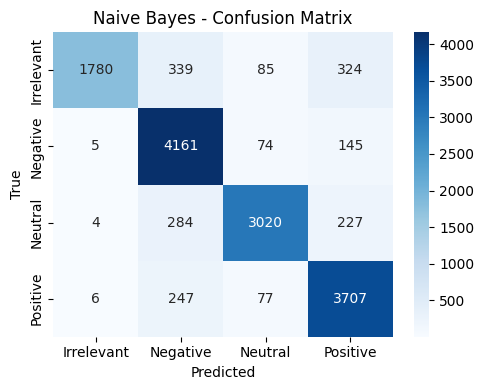


=== Linear SVM ===
Accuracy: 0.9449

Per-class metrics:
Irrelevant   - Precision: 0.9505, Recall: 0.9197, F1: 0.9349
Negative     - Precision: 0.9576, Recall: 0.9528, F1: 0.9552
Neutral      - Precision: 0.9451, Recall: 0.9505, F1: 0.9478
Positive     - Precision: 0.9279, Recall: 0.9472, F1: 0.9375

Classification report:
               precision    recall  f1-score   support

  Irrelevant       0.95      0.92      0.93      2528
    Negative       0.96      0.95      0.96      4385
     Neutral       0.95      0.95      0.95      3535
    Positive       0.93      0.95      0.94      4037

    accuracy                           0.94     14485
   macro avg       0.95      0.94      0.94     14485
weighted avg       0.95      0.94      0.94     14485

Confusion matrix:
 [[2325   60   49   94]
 [  32 4178   62  113]
 [  38   47 3360   90]
 [  51   78   84 3824]]


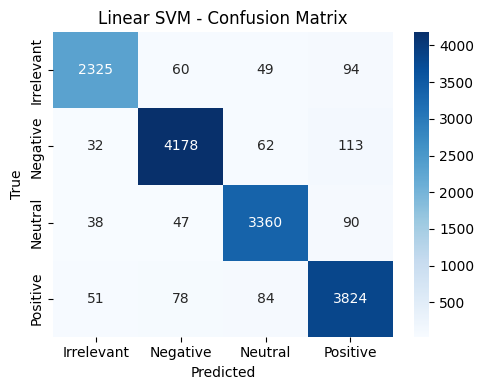


Models + vectorizer saved to sentiment_models.joblib


In [77]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import joblib

# ---------- Stopwords ----------
STOP_WORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she",
    "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
    "these", "those", "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of",
    "at", "by", "for", "with", "about", "against", "between", "into", "through",
    "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then",
    "once", "here", "there", "when", "where", "why", "how", "all", "any",
    "both", "each", "few", "more", "most", "other", "some", "such", "no",
    "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s",
    "t", "can", "will", "just", "don", "should", "now"
}

# ---------- Preprocessing ----------
def preprocess_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return " ".join(tokens)

# ---------- Load & clean data ----------
df = pd.read_csv("twitter_training.csv", header=None,
                 names=["Tweet ID", "Entity", "Sentiment", "Tweet content"])

df["Tweet_clean"] = df["Tweet content"].apply(preprocess_tweet)
df = df[df["Tweet_clean"] != ""].reset_index(drop=True)

X = df["Tweet_clean"]
y = df["Sentiment"]

# ---------- Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- TF-IDF ----------
tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.95,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ---------- Models ----------
models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced", max_iter=5000, random_state=42)
}

# ---------- Evaluation function ----------
def evaluate_model(name, clf, X_train, X_test, y_train, y_test, labels):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=None, labels=labels)
    rec  = recall_score(y_test, y_pred, average=None, labels=labels)
    f1   = f1_score(y_test, y_pred, average=None, labels=labels)
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("\nPer-class metrics:")
    for cls, p, r, f in zip(labels, prec, rec, f1):
        print(f"{cls:12} - Precision: {p:.4f}, Recall: {r:.4f}, F1: {f:.4f}")
    
    print("\nClassification report:\n", classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    print("Confusion matrix:\n", cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return clf

# ---------- Train & evaluate each model ----------
labels = sorted(y.unique())  # e.g. ['Irrelevant', 'Negative', 'Neutral', 'Positive']

trained_models = {}
for name, clf in models.items():
    trained = evaluate_model(name, clf, X_train_tfidf, X_test_tfidf, y_train, y_test, labels)
    trained_models[name] = trained

joblib.dump((tfidf, trained_models), "sentiment_models.joblib")
print("\nModels + vectorizer saved to sentiment_models.joblib")

In [79]:
# Visualization and WordCloud :

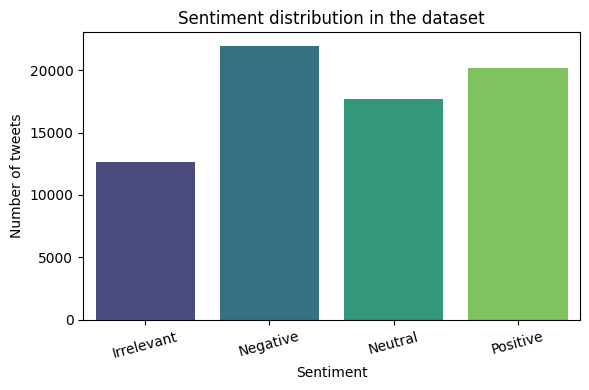

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

STOP_WORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she",
    "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
    "these", "those", "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of",
    "at", "by", "for", "with", "about", "against", "between", "into", "through",
    "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then",
    "once", "here", "there", "when", "where", "why", "how", "all", "any",
    "both", "each", "few", "more", "most", "other", "some", "such", "no",
    "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s",
    "t", "can", "will", "just", "don", "should", "now"
}

def preprocess_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return " ".join(tokens)

df = pd.read_csv("twitter_training.csv", header=None,
                 names=["Tweet ID", "Entity", "Sentiment", "Tweet content"])
df["Tweet_clean"] = df["Tweet content"].apply(preprocess_tweet)
df = df[df["Tweet_clean"] != ""].reset_index(drop=True)

plt.figure(figsize=(6, 4))
sent_counts = df["Sentiment"].value_counts().sort_index()

sns.barplot(
    x=sent_counts.index,
    y=sent_counts.values,
    hue=sent_counts.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.title("Sentiment distribution in the dataset")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

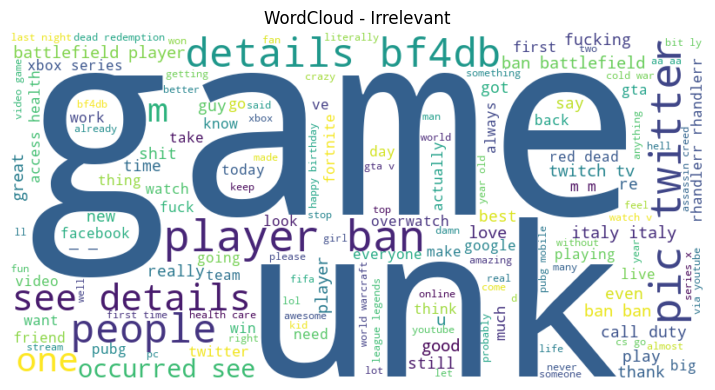

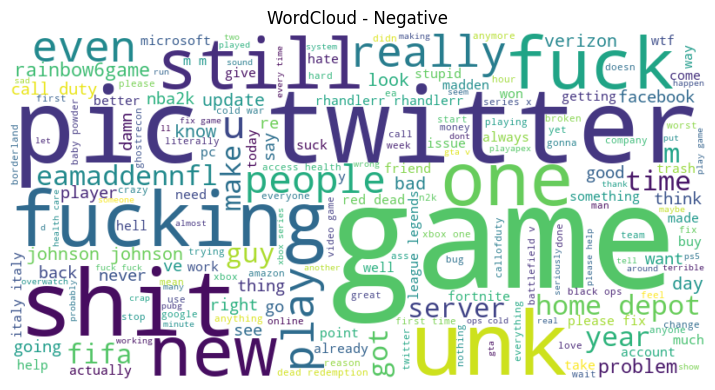

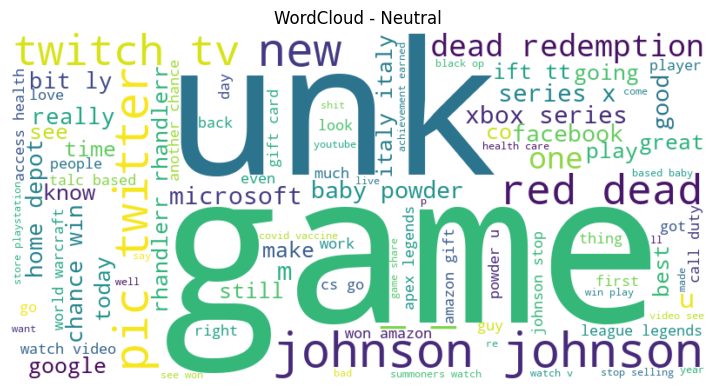

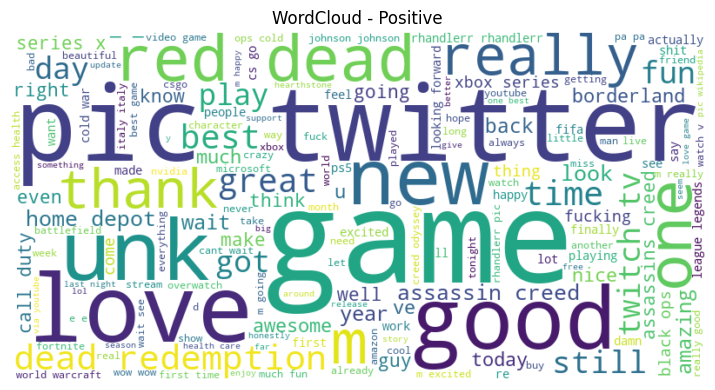

In [91]:
texts_by_sentiment = {
    sent: " ".join(df.loc[df["Sentiment"] == sent, "Tweet_clean"].dropna().astype(str))
    for sent in sorted(df["Sentiment"].unique())
}

for sent, text in texts_by_sentiment.items():
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=200,
        colormap="viridis",
        min_font_size=10
    ).generate(text)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {sent}")
    plt.tight_layout()
    plt.show()